In [3]:
#Load the cleaned dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (from Step 6)
df = pd.read_csv("../Dataset/cleaned/superstore_cleaned.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Set a consistent visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


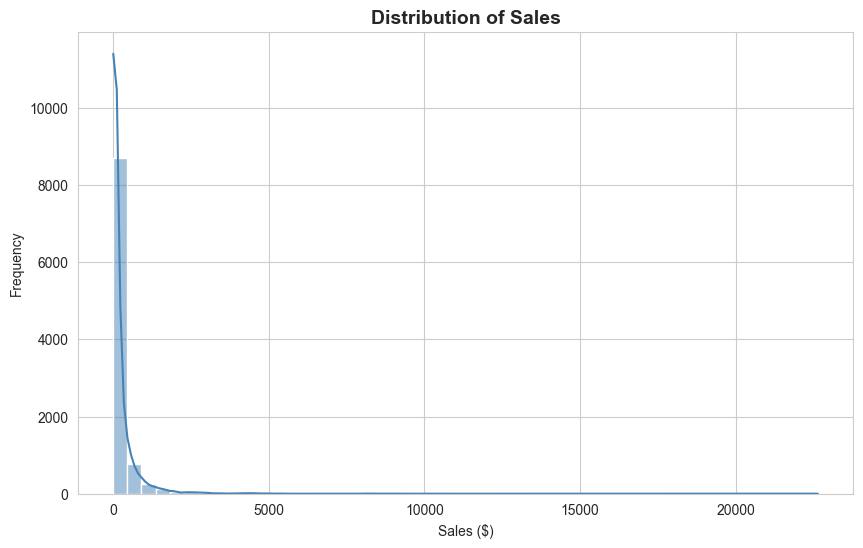

In [4]:
#Part 1: Univariate Analysis (Distribution of Single Variables)

# Sales Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

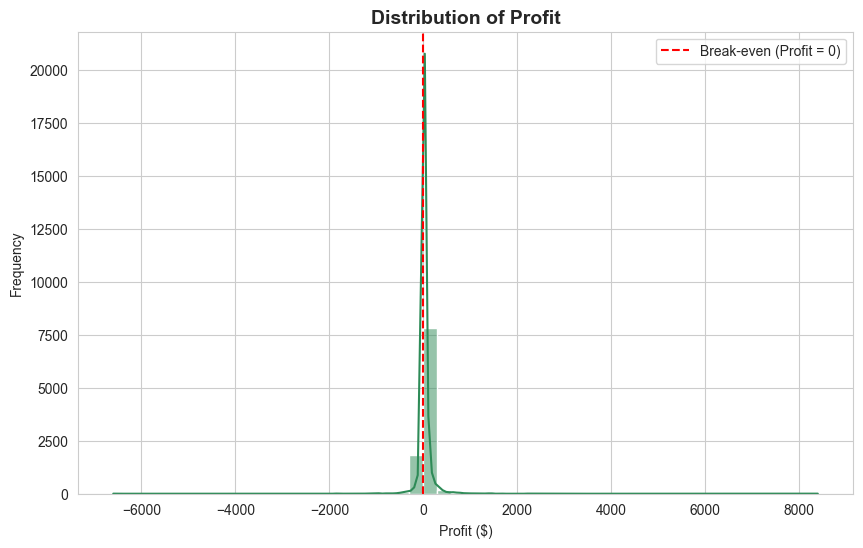

In [5]:
#Profit Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=50, kde=True, color='seagreen')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Break-even (Profit = 0)')
plt.title('Distribution of Profit', fontsize=14, fontweight='bold')
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

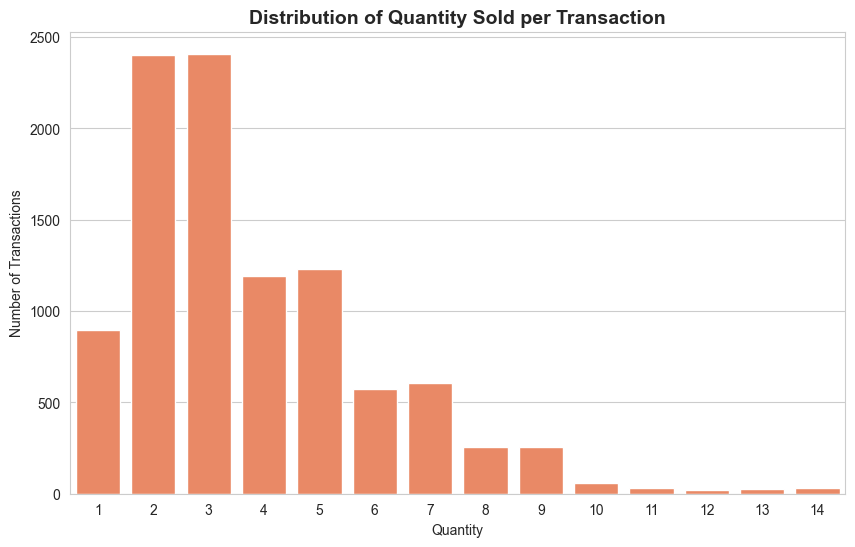

In [6]:
#Quantity Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Quantity', data=df, color='coral')
plt.title('Distribution of Quantity Sold per Transaction', fontsize=14, fontweight='bold')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.show()

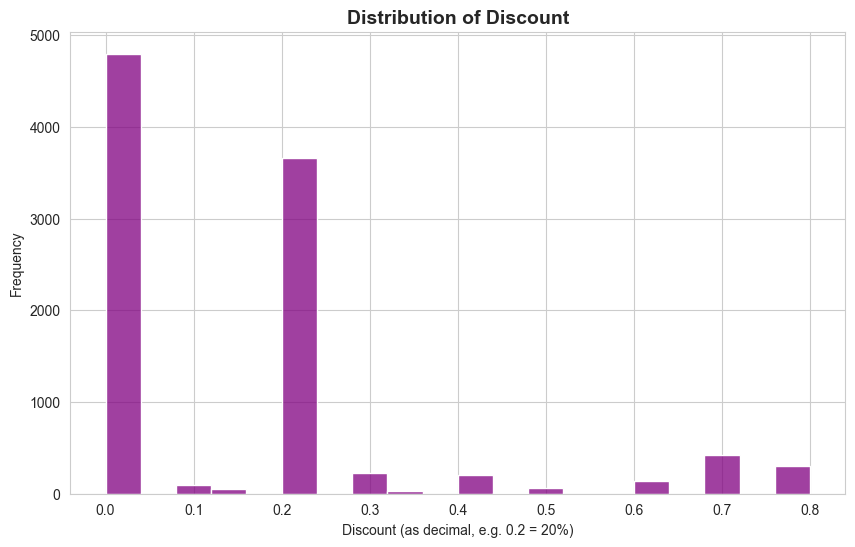

In [7]:
#Discount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Discount'], bins=20, kde=False, color='purple')
plt.title('Distribution of Discount', fontsize=14, fontweight='bold')
plt.xlabel('Discount (as decimal, e.g. 0.2 = 20%)')
plt.ylabel('Frequency')
plt.show()

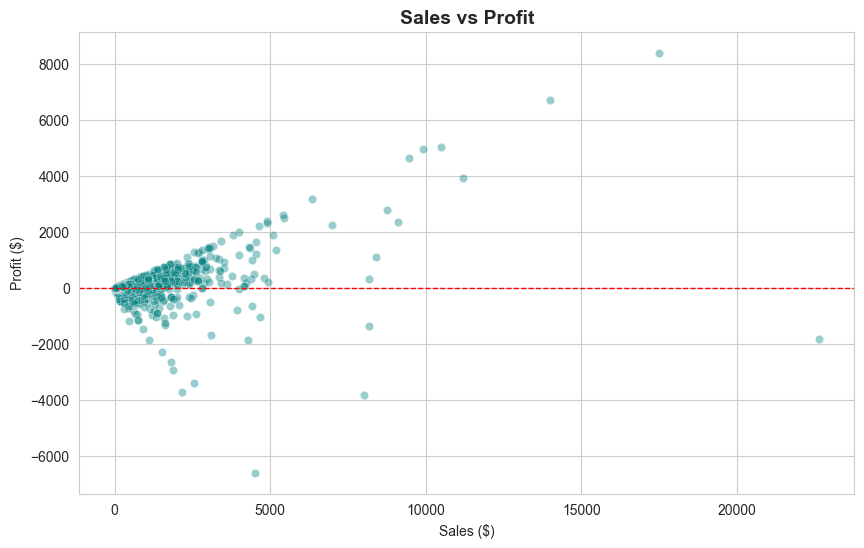

In [8]:
#Part 2: Bivariate Analysis (Relationships Between Variables)

#Sales vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.4, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Sales vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.show()

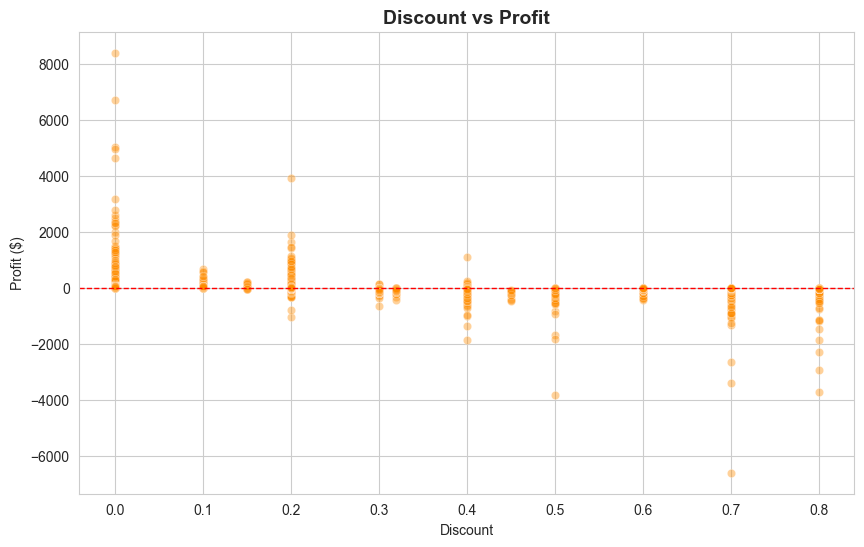

In [9]:
# Discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.4, color='darkorange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.show()

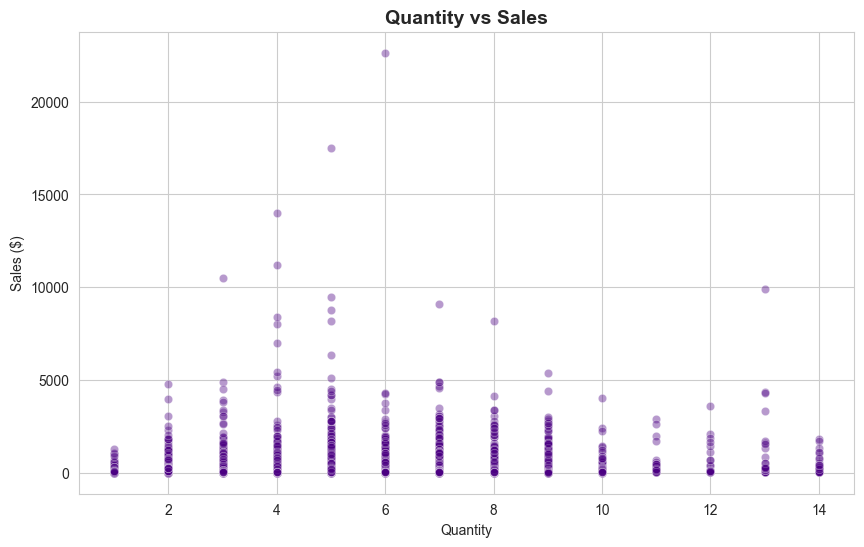

In [10]:
#Quantity vs Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quantity', y='Sales', data=df, alpha=0.4, color='indigo')
plt.title('Quantity vs Sales', fontsize=14, fontweight='bold')
plt.xlabel('Quantity')
plt.ylabel('Sales ($)')
plt.show()

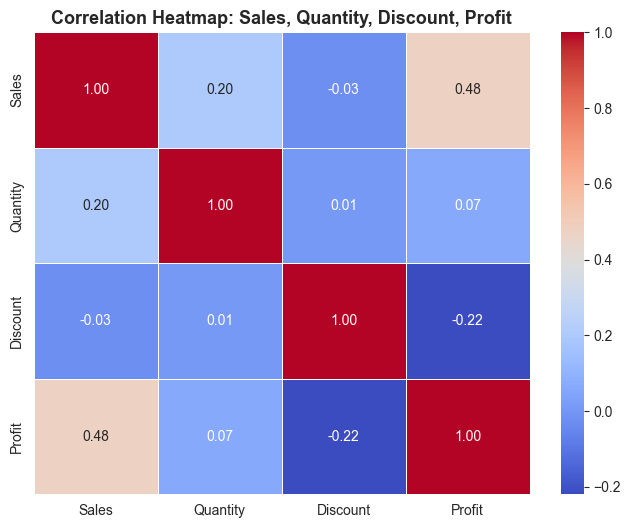

In [11]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit', fontsize=13, fontweight='bold')
plt.show()

C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\4275567450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ax=axes[0], palette='Blues_d', errorbar=None)
C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\4275567450.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator=sum, ax=axes[1], palette='Greens_d', errorbar=None)


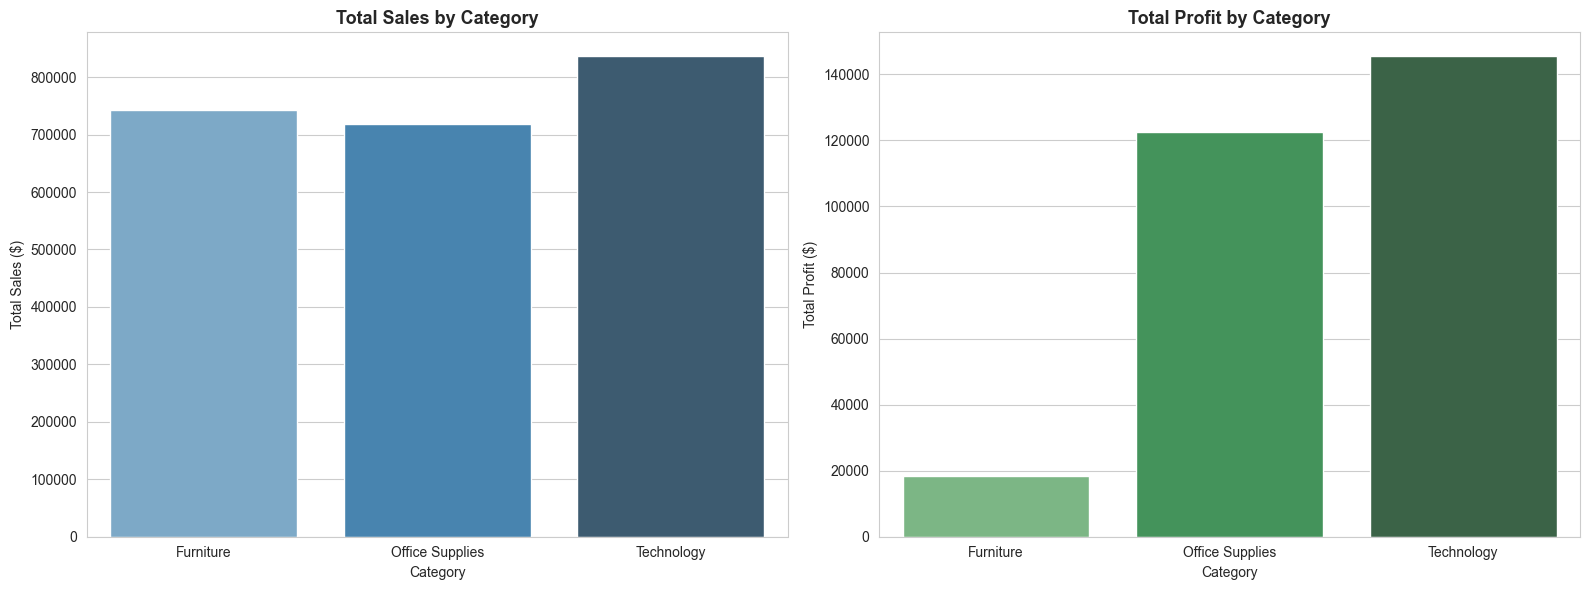

In [12]:
#  Part 3: Categorical Analysis
#  Sales & Profit by Category

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ax=axes[0], palette='Blues_d', errorbar=None)
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')

sns.barplot(x='Category', y='Profit', data=df, estimator=sum, ax=axes[1], palette='Greens_d', errorbar=None)
axes[1].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.show()

C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\3584082827.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=df, estimator=sum, palette='viridis', errorbar=None)


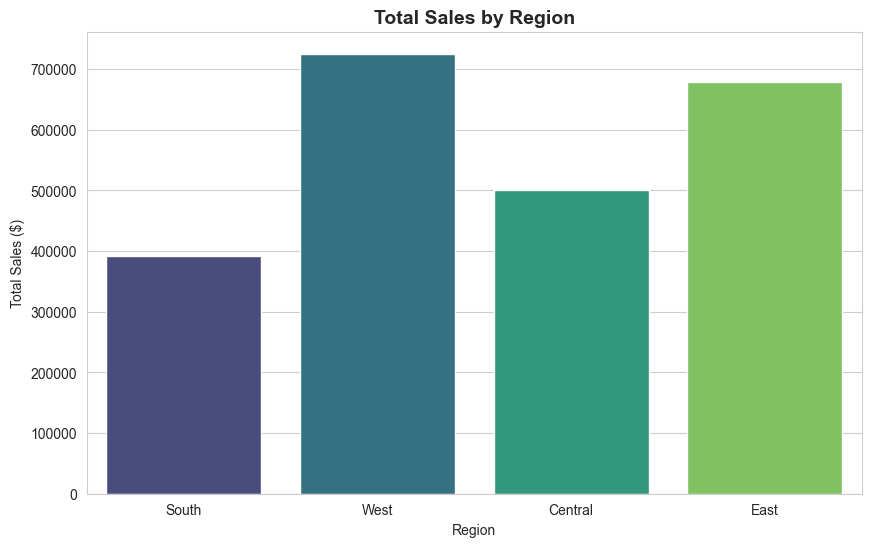

In [13]:
#Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum, palette='viridis', errorbar=None)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.show()

C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\960486899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Sales', data=df, estimator=sum, palette='magma', errorbar=None)


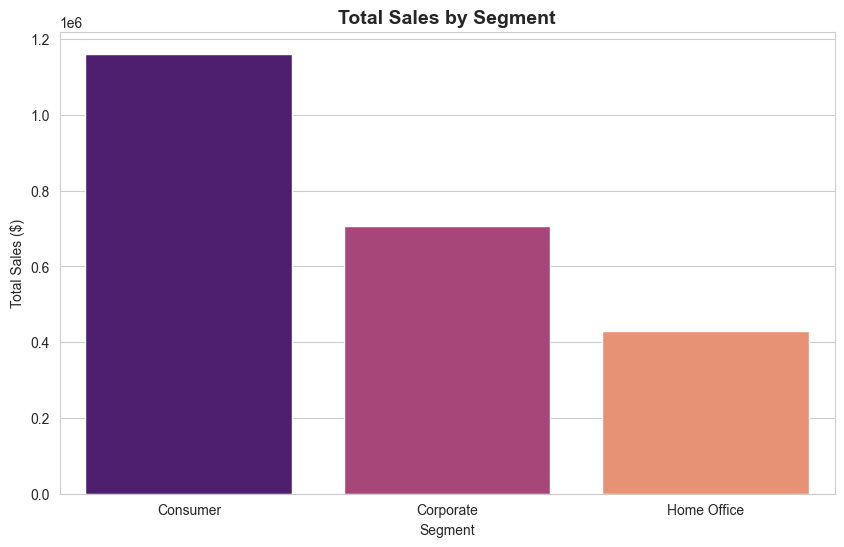

In [14]:
#Sales by Segment
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum, palette='magma', errorbar=None)
plt.title('Total Sales by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.show()

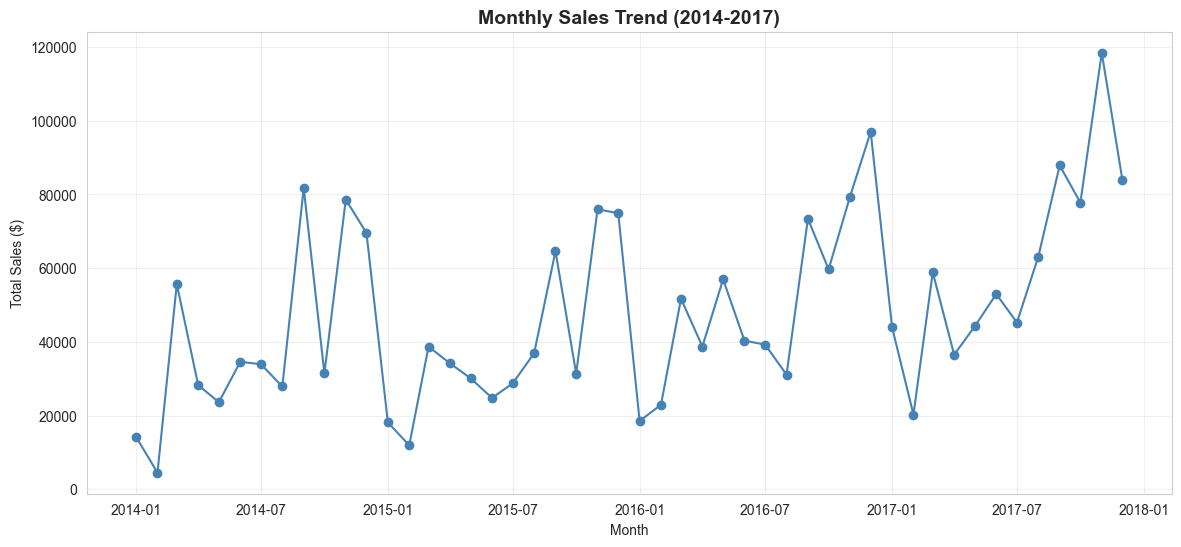

In [15]:
#Part 4: Time Analysis
# Monthly Sales Trend (Line Chart)

# Prepare monthly aggregated data
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', color='steelblue', linewidth=1.5)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

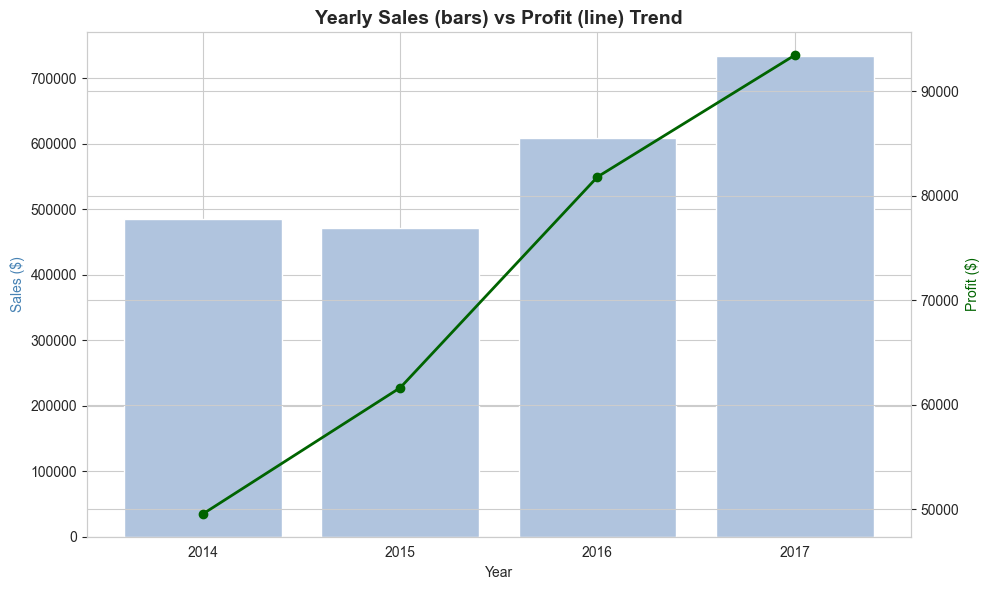

In [16]:
#Yearly Sales & Profit Trend
yearly_data = df.groupby(df['Order Date'].dt.year)[['Sales', 'Profit']].sum().reset_index()
yearly_data.columns = ['Year', 'Sales', 'Profit']

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(yearly_data['Year'], yearly_data['Sales'], color='lightsteelblue', label='Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sales ($)', color='steelblue')
ax1.set_xticks(yearly_data['Year'])

ax2 = ax1.twinx()
ax2.plot(yearly_data['Year'], yearly_data['Profit'], color='darkgreen', marker='o', linewidth=2, label='Profit')
ax2.set_ylabel('Profit ($)', color='darkgreen')

plt.title('Yearly Sales (bars) vs Profit (line) Trend', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\1959321184.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='crest')


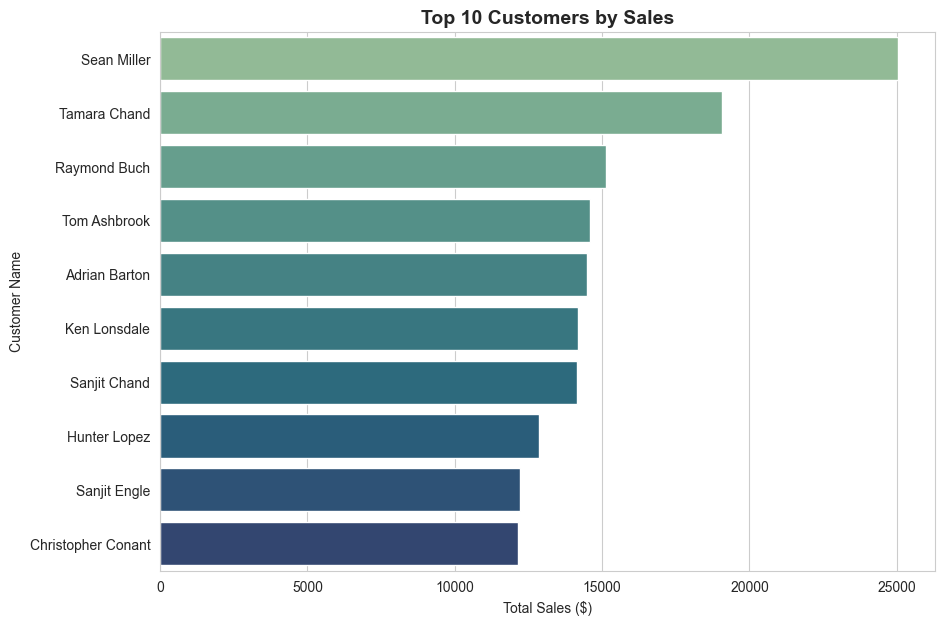

In [18]:
#Part 5: Customer & Product Analysis
# Top 10 Customers by Sales (Horizontal Bar Chart)
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='crest')
plt.title('Top 10 Customers by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.show()

C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\665204914.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Greens_d')
C:\Users\Yamuna S\AppData\Local\Temp\ipykernel_32796\665204914.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10_products.values, y=bottom_10_products.index, ax=axes[1], palette='Reds_d')


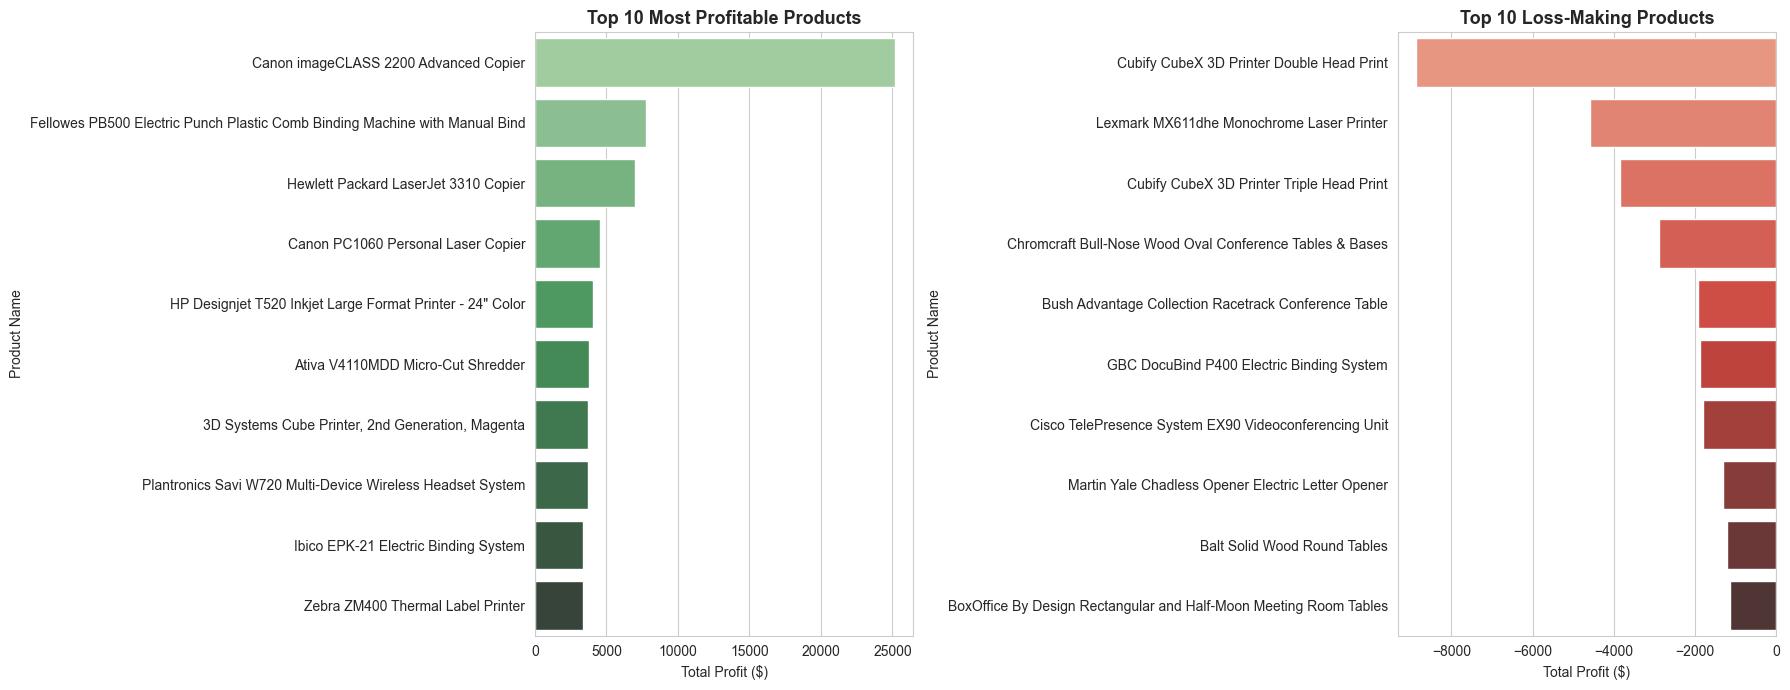

In [19]:
# Top 10 Products by Profit (and worst 10, side by side)
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

top_10_products = product_profit.head(10)
bottom_10_products = product_profit.tail(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Greens_d')
axes[0].set_title('Top 10 Most Profitable Products', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')

sns.barplot(x=bottom_10_products.values, y=bottom_10_products.index, ax=axes[1], palette='Reds_d')
axes[1].set_title('Top 10 Loss-Making Products', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.show()
